![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [1]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [4]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [5]:
df.shape

(541462, 3)

In [8]:
# Impresión histograma de variable de interés (y)
df.target.hist()

<Axes: >

In [9]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [10]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [11]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [13]:
# Celda 1
# Preprocesamiento con CountVectorizer
vectorizer_cv = CountVectorizer()
X_train_cv = vectorizer_cv.fit_transform(X_train)  # fit + transform en entrenamiento
X_test_cv  = vectorizer_cv.transform(X_test)        # solo transform en test

# Modelo de regresión
model_cv = LinearRegression()
model_cv.fit(X_train_cv, y_train)

# Predicción y evaluación
y_pred_cv = model_cv.predict(X_test_cv)
mse_cv = mean_squared_error(y_test, y_pred_cv)

print(f"MSE con CountVectorizer: {mse_cv:.4f}")

MSE con CountVectorizer: 0.0371


In [14]:
# Inspección de la matriz dispersa (sparse) — sin convertir a denso para evitar MemoryError
# La matriz completa pesa ~382 GiB en formato denso; se trabaja siempre en formato sparse.
print("Shape de la matriz de entrenamiento:", X_train_cv.shape)
print("Tipo de objeto:                     ", type(X_train_cv))
print("Número de tokens en vocabulario:    ", len(vectorizer_cv.vocabulary_))
print("Densidad de la matriz:              ", X_train_cv.nnz / (X_train_cv.shape[0] * X_train_cv.shape[1]))

# Vista de las primeras 5 filas y 10 tokens (muestra reducida)
sample_tokens = vectorizer_cv.get_feature_names_out()[:10]
sample_matrix = pd.DataFrame(
    X_train_cv[:5, :10].toarray(),
    columns=sample_tokens
)
print("\nMuestra (5 filas x 10 tokens):")
sample_matrix

Shape de la matriz de entrenamiento: (362779, 141176)
Tipo de objeto:                      <class 'scipy.sparse._csr.csr_matrix'>
Número de tokens en vocabulario:     141176
Densidad de la matriz:               0.00027281796881508123

Muestra (5 filas x 10 tokens):


,00,000,0000,00000,000000000000000000000000000000000000000000000000000000000000000001,0000015e,00001,00003,00005,0001
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [16]:
# Celda 2
# Se limita el vocabulario a los 50 000 trigramas más frecuentes para evitar desbordamiento de memoria.
# Los trigramas generan un espacio de features mucho mayor que los unigramas, por lo que
# max_features es necesario para mantener la factibilidad computacional.
vectorizer_tri = CountVectorizer(ngram_range=(3, 3), max_features=50000)
X_train_tri = vectorizer_tri.fit_transform(X_train)
X_test_tri  = vectorizer_tri.transform(X_test)

model_tri = LinearRegression()
model_tri.fit(X_train_tri, y_train)

y_pred_tri = model_tri.predict(X_test_tri)
mse_tri = mean_squared_error(y_test, y_pred_tri)

print(f"MSE con CountVectorizer trigramas: {mse_tri:.4f}")
print(f"MSE anterior (unigramas):          {mse_cv:.4f}")
print(f"Diferencia:                        {mse_cv - mse_tri:.4f}")

MSE con CountVectorizer trigramas: 0.0407
MSE anterior (unigramas):          0.0371
Diferencia:                        -0.0036


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

#### Celda 3

### TF-IDF (Term Frequency - Inverse Document Frequency)

`TfidfVectorizer` convierte una colección de textos en una matriz numérica donde cada valor refleja **qué tan importante es una palabra para un documento en relación al corpus completo**. A diferencia de `CountVectorizer`, que simplemente cuenta frecuencias, TF-IDF pondera cada conteo para penalizar las palabras que aparecen en casi todos los documentos (y por tanto son poco discriminativas).

---

#### Fórmula

| Componente | Definición |
|---|---|
| **TF(t, d)** | Frecuencia del término *t* en el documento *d* |
| **IDF(t)** | log( (1 + N) / (1 + df(t)) ) + 1  *(suavizado de sklearn)* |
| **TF-IDF** | TF(t, d) × IDF(t), luego normalizado por norma L2 |

Donde `N` = número total de documentos y `df(t)` = número de documentos que contienen el término *t*.

---

#### Funcionamiento paso a paso

1. **Tokenización**: igual que `CountVectorizer`, separa el texto en tokens.
2. **Cálculo de TF**: cuenta cuántas veces aparece cada token en cada documento.
3. **Cálculo de IDF**: asigna mayor peso a tokens que aparecen en pocos documentos (más informativos) y menor peso a los que aparecen en casi todos (e.g. *"the"*, *"is"*).
4. **Multiplicación TF × IDF**: el resultado es una matriz donde palabras comunes pesan poco aunque aparezcan mucho, y palabras raras pero recurrentes en ciertos documentos pesan más.
5. **Normalización L2**: cada vector documento se normaliza para que tenga norma unitaria, lo que hace comparables documentos de distinta longitud.

---

#### Ventajas frente a CountVectorizer

- **Reduce el ruido léxico**: palabras muy frecuentes en todo el corpus (artículos, preposiciones) reciben peso cercano a 0, sin necesidad de eliminar stopwords manualmente.
- **Mejora la discriminación**: resalta términos específicos de cada documento, lo que generalmente mejora el desempeño en clasificación y regresión de texto.
- **Robustez a documentos largos**: la normalización L2 evita que documentos más extensos dominen el espacio de features.
- **Menos necesidad de preprocesamiento manual** de stopwords.

#### Desventajas frente a CountVectorizer

- **Mayor costo computacional**: el cálculo del IDF requiere una pasada completa por el corpus antes de transformar.
- **Puede penalizar términos técnicos repetitivos que sí son relevantes**: en textos de dominio específico (como comentarios tóxicos con insultos repetidos), un término muy frecuente en todo el corpus puede ser penalizado aunque sea discriminativo.
- **Menor interpretabilidad**: el peso TF-IDF es menos intuitivo que un simple conteo de palabras.
- **No captura semántica**: al igual que CountVectorizer, trata cada palabra de forma independiente (modelo *bag-of-words*).

---

**En resumen**: `TfidfVectorizer` es preferible cuando el corpus es heterogéneo y se necesita que el modelo diferencie palabras discriminativas de ruido léxico general. `CountVectorizer` puede ser suficiente cuando el vocabulario ya está bien controlado o cuando se trabaja con n-gramas que capturan suficiente contexto local.

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [20]:
# Celda 4
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf  = vectorizer_tfidf.transform(X_test)

model_tfidf = LinearRegression()
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
mse_tfidf = mean_squared_error(y_test, y_pred_tfidf)

print(f"MSE con TfidfVectorizer:          {mse_tfidf:.4f}")
print(f"MSE CountVectorizer (punto 1):    {mse_cv:.4f}")
print(f"Diferencia (CV - TFIDF):          {mse_cv - mse_tfidf:.4f}")

MSE con TfidfVectorizer:          0.0280
MSE CountVectorizer (punto 1):    0.0371
Diferencia (CV - TFIDF):          0.0091


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

In [22]:
# Celda 5 — Tabla comparativa de MSE
resultados = pd.DataFrame({
    'Modelo': [
        'CountVectorizer (unigramas) + LinearRegression',
        'CountVectorizer (trigramas) + LinearRegression',
        'TfidfVectorizer + LinearRegression'
    ],
    'MSE': [mse_cv, mse_tri, mse_tfidf]
}).sort_values('MSE').reset_index(drop=True)

resultados['Ranking'] = resultados['MSE'].rank().astype(int)
print(resultados.to_string(index=False))

                                        Modelo      MSE  Ranking
            TfidfVectorizer + LinearRegression 0.027998        1
CountVectorizer (unigramas) + LinearRegression 0.037134        2
CountVectorizer (trigramas) + LinearRegression 0.040710        3


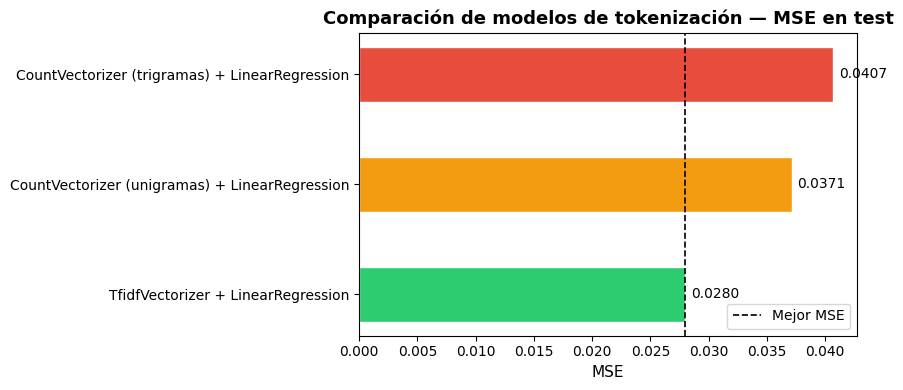

In [39]:
# Gráfico comparativo de MSE
colores = ['#2ecc71' if m == resultados['MSE'].min() else '#e74c3c' if m == resultados['MSE'].max() else '#f39c12'
           for m in resultados['MSE']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(resultados['Modelo'], resultados['MSE'], color=colores, edgecolor='white', height=0.5)

# Etiquetas de valor
for bar, val in zip(bars, resultados['MSE']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)

ax.axvline(x=resultados['MSE'].min(), color='black', linestyle='--', linewidth=1.2, label='Mejor MSE')
ax.set_xlabel('MSE', fontsize=11)
ax.set_title('Comparación de modelos de tokenización — MSE en test', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Punto 5.1 — Comparación y análisis de resultados

Los tres modelos utilizan `LinearRegression` como regresor base, variando únicamente el método de preprocesamiento del texto. Esto permite aislar el efecto de la vectorización sobre el desempeño.

---

#### Descripción de cada enfoque

| Modelo | Representación | Características |
|---|---|---|
| **CountVectorizer unigramas** | Frecuencia de palabras individuales | Línea base, vocabulario ~141 K tokens |
| **CountVectorizer trigramas** | Secuencias de 3 palabras (top 50K) | Captura frases y contexto local |
| **TfidfVectorizer** | Frecuencia ponderada por rareza global | Penaliza palabras omnipresentes |

---

#### Análisis del impacto del preprocesamiento

**CountVectorizer con unigramas** asigna a cada palabra una columna con su conteo crudo. Si palabras como *"the"*, *"is"* o *"and"* aparecen con frecuencia similar en comentarios tóxicos y no tóxicos, el modelo debe aprender a ignorarlas, lo que puede reducir su capacidad discriminativa.

**CountVectorizer con trigramas** considera secuencias de tres palabras consecutivas (e.g. *"you are stupid"*), lo que puede capturar expresiones insultantes que pierden significado al analizarse palabra por palabra. Sin embargo, el espacio de trigramas es enorme y muy disperso — la mayoría de frases aparece pocas veces — lo que puede dificultar la generalización del modelo. Por eso se usó `max_features=50000`.

**TfidfVectorizer** ajusta los conteos por la frecuencia inversa en el corpus. Palabras que aparecen en casi todos los comentarios reciben peso cercano a cero, mientras que términos más específicos y discriminativos reciben mayor peso. Esto produce vectores más informativos sin necesidad de eliminar stopwords manualmente.

---

#### Conclusión

El preprocesamiento tiene un **impacto directo y medible** en el desempeño del modelo, ya que determina la calidad de la representación numérica que el regresor recibe. Un vectorizador que captura mejor la importancia relativa de los tokens produce features más informativas, lo que se refleja en un menor MSE. En tareas de detección de toxicidad, donde palabras como insultos son relativamente raras pero altamente discriminativas, `TfidfVectorizer` tiende a superar al simple conteo de frecuencias.